**Source:** https://www.kaggle.com/datasets/sobhanmoosavi/us-traffic-congestions-2016-2022

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-traffic-congestions-2016-2022")

print("Path to dataset files:", path)

# Step into sample subfolder
sample_folder = os.path.join(path, "us_congestion_2016_2022_sample_2m")
file_list = os.listdir(sample_folder)
print("Files in sample folder:", file_list)

csv_path = os.path.join(sample_folder, file_list[0])
df = pd.read_csv(csv_path)
print(df['Severity'].value_counts())
df = df[df['Severity'] != 4]

print("Shape:", df.shape)
print(df.info())
print(df.head())
print(df.describe())
df.isnull().sum().sort_values(ascending=False)

100%|██████████| 2.31G/2.31G [01:19<00:00, 31.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-traffic-congestions-2016-2022/versions/3
Files in sample folder: ['us_congestion_2016_2022_sample_2m.csv']
Severity
1    933976
2    525011
0    484824
3     56180
4         9
Name: count, dtype: int64
Shape: (1999991, 30)
<class 'pandas.core.frame.DataFrame'>
Index: 1999991 entries, 0 to 1999999
Data columns (total 30 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   ID                             object 
 1   Severity                       int64  
 2   Start_Lat                      float64
 3   Start_Lng                      float64
 4   StartTime                      object 
 5   EndTime                        object 
 6   Distance(mi)                   float64
 7   DelayFromTypicalTraffic(mins)  float64
 8   DelayFromFreeFlowSpeed(mins)   float64
 9   Congestion_Speed               object 
 10  Description                    object 
 11  Street              

,0
Weather_Event,1871984
Precipitation(in),825185
WindChill(F),759204
WindSpeed(mph),189470
Visibility(mi),58370
Weather_Conditions,57097
WindDir,47385
Humidity(%),46167
Temperature(F),43957
Pressure(in),41123


In [ ]:
# Drop unnecessary columns
columns_to_drop = [
    'ID', 'EndTime', 'Description', 'Street',
    'City', 'State', 'County', 'Country', 'ZipCode', 'LocalTimeZone',
    'WeatherStation_AirportCode', 'WeatherTimeStamp', 'Weather_Event'
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop rows where StartTime is missing
df = df.dropna(subset=['StartTime'])

# Convert StartTime to datetime and remove timezone
df['StartTime'] = pd.to_datetime(df['StartTime'], utc=True, errors='coerce')
df['Hour'] = df['StartTime'].dt.hour
df['DayOfWeek'] = df['StartTime'].dt.dayofweek  # Monday=0, Sunday=6
df['Month'] = df['StartTime'].dt.month
df.drop(columns=['StartTime'], inplace=True)

weather_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                'Visibility(mi)', 'WindSpeed(mph)', 'WindChill(F)', 'Precipitation(in)']
for col in weather_cols:
    df[col].fillna(df[col].median(), inplace=True)

df['WindDir'].fillna('Unknown', inplace=True)
df['Weather_Conditions'].fillna('Unknown', inplace=True)

weather_conditions = df['Weather_Conditions'].value_counts()
common_weather = weather_conditions[weather_conditions > 1000].index
df['Weather_Conditions'] = np.where(
    df['Weather_Conditions'].isin(common_weather),
    df['Weather_Conditions'],
    'Other'
)

ordinal_encoder = OrdinalEncoder(categories=[['Fast', 'Moderate', 'Slow']])
df[['Congestion_Speed']] = ordinal_encoder.fit_transform(df[['Congestion_Speed']])

# Fix inconsistent WindDir values by mapping similar entries to a single standard value
winddir_mapping = {
    'North': 'N',
    'N': 'N',
    'South': 'S',
    'S': 'S',
    'East': 'E',
    'E': 'E',
    'West': 'W',
    'W': 'W',
    'NNE': 'NNE',
    'ENE': 'ENE',
    'ESE': 'ESE',
    'SSE': 'SSE',
    'SSW': 'SSW',
    'SW': 'SW',
    'WSW': 'WSW',
    'WNW': 'WNW',
    'NW': 'NW',
    'NNW': 'NNW',
    'NE': 'NE',
    'SE': 'SE',
    'Calm': 'CALM',
    'CALM': 'CALM',
    'Variable': 'VAR',
    'VAR': 'VAR',
    'Unknown': 'Unknown'
}

# Apply the mapping to WindDir
df['WindDir'] = df['WindDir'].map(lambda x: winddir_mapping.get(x, 'Unknown'))

# One-hot encode categorical variables
cat_cols = ['WindDir', 'Weather_Conditions']
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Scale selected numeric features
weather_scale_cols = ['Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                      'Visibility(mi)', 'WindSpeed(mph)', 'Precipitation(in)']
scaler_weather = StandardScaler()
df[weather_scale_cols] = scaler_weather.fit_transform(df[weather_scale_cols])

traffic_scale_cols = ['Distance(mi)', 'DelayFromTypicalTraffic(mins)',
                      'DelayFromFreeFlowSpeed(mins)']
scaler_traffic = MinMaxScaler()
df[traffic_scale_cols] = scaler_traffic.fit_transform(df[traffic_scale_cols])

/tmp/ipython-input-2-1035598708.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2-1035598708.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X = df.drop(columns=['Severity'])
y = df['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-5-3695634470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


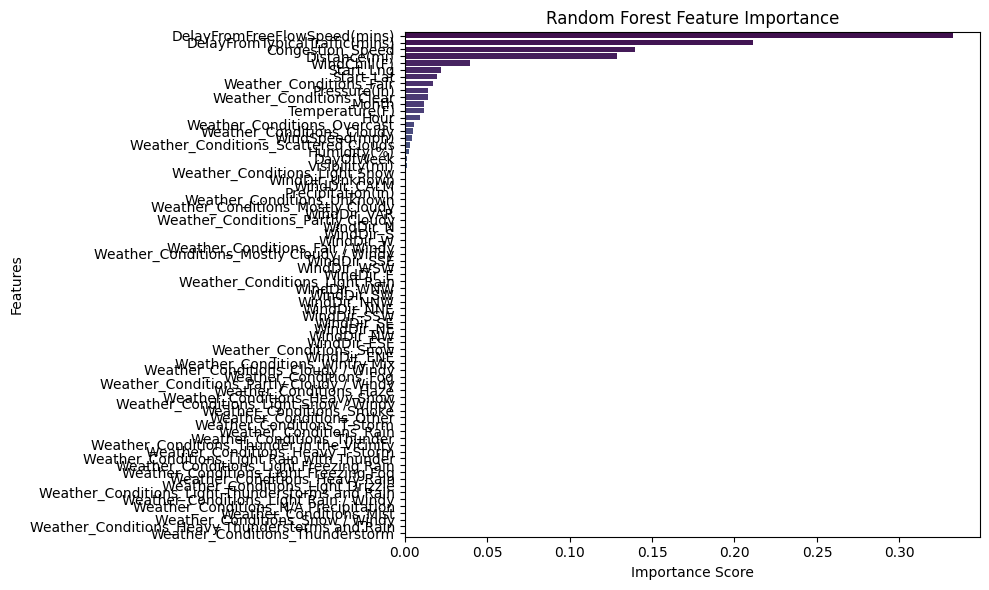


Feature Importance Scores:
                                        Feature  Importance
                   DelayFromFreeFlowSpeed(mins)    0.332199
                  DelayFromTypicalTraffic(mins)    0.210920
                               Congestion_Speed    0.139958
                                   Distance(mi)    0.128499
                                   WindChill(F)    0.039486
                                      Start_Lng    0.022160
                                      Start_Lat    0.019672
                        Weather_Conditions_Fair    0.017265
                                   Pressure(in)    0.014336
                       Weather_Conditions_Clear    0.013966
                                          Month    0.011770
                                 Temperature(F)    0.011561
                                           Hour    0.009136
                    Weather_Conditions_Overcast    0.005480
                      Weather_Conditions_Cloudy    0.005054
            

In [ ]:
# Get feature importances from the model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

Accuracy: 0.66

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.61      0.66     96589
           1       0.67      0.76      0.72    186735
           2       0.59      0.58      0.59    104859
           3       0.74      0.21      0.33     11451

    accuracy                           0.66    399634
   macro avg       0.68      0.54      0.57    399634
weighted avg       0.67      0.66      0.66    399634


Confusion Matrix:
[[ 58512  31405   6672      0]
 [ 15940 142670  27991    134]
 [  6391  36744  61002    722]
 [    16   1152   7832   2451]]


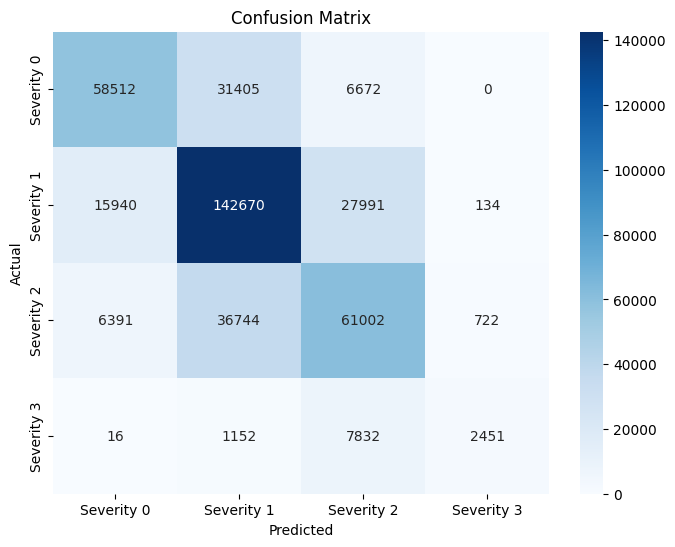

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Apply threshold
threshold = 0.0005
selected_features = importance_df[importance_df['Importance'] >= threshold]['Feature']

In [ ]:
X = df[selected_features]
y = df['Severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Retrain RF after feature selection
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-12-4125673753.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


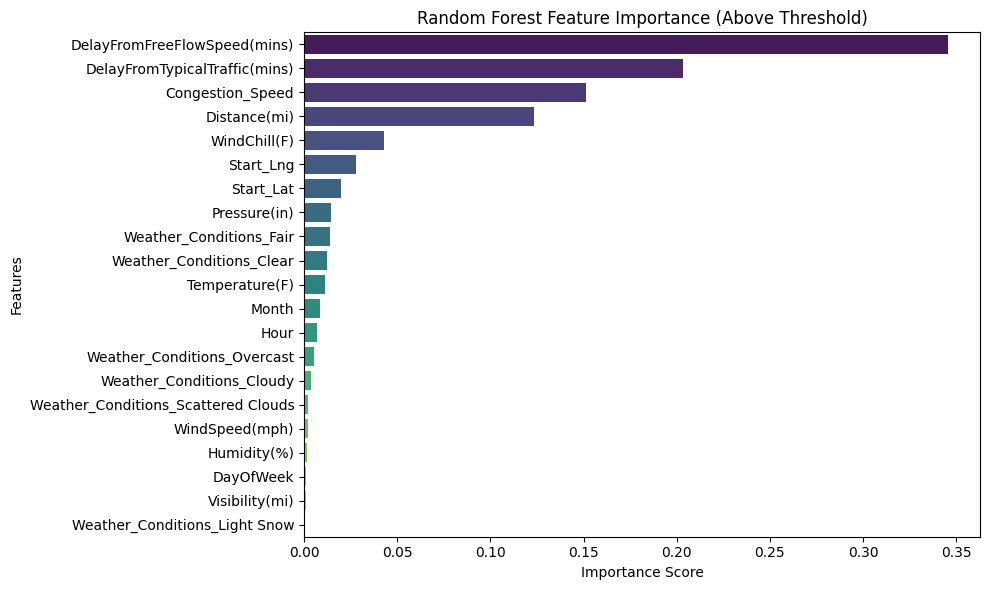


Feature Importance Scores (Above Threshold):
                            Feature  Importance
       DelayFromFreeFlowSpeed(mins)    0.345463
      DelayFromTypicalTraffic(mins)    0.203205
                   Congestion_Speed    0.151516
                       Distance(mi)    0.123466
                       WindChill(F)    0.043174
                          Start_Lng    0.027861
                          Start_Lat    0.019588
                       Pressure(in)    0.014552
            Weather_Conditions_Fair    0.014095
           Weather_Conditions_Clear    0.012425
                     Temperature(F)    0.011225
                              Month    0.008680
                               Hour    0.006965
        Weather_Conditions_Overcast    0.005593
          Weather_Conditions_Cloudy    0.003550
Weather_Conditions_Scattered Clouds    0.002315
                     WindSpeed(mph)    0.002171
                        Humidity(%)    0.001601
                          DayOfWeek    0.0

In [ ]:
# Get feature importances from the model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance (Above Threshold)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print raw importance values
print("\nFeature Importance Scores (Above Threshold):")
print(importance_df.to_string(index=False))

Accuracy: 0.68

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.64      0.67     96589
           1       0.70      0.75      0.72    186735
           2       0.62      0.61      0.61    104859
           3       0.70      0.48      0.57     11451

    accuracy                           0.68    399634
   macro avg       0.68      0.62      0.64    399634
weighted avg       0.68      0.68      0.68    399634


Confusion Matrix:
[[ 62061  28271   6257      0]
 [ 18105 139955  28321    354]
 [  7272  32002  63636   1949]
 [    11    967   5017   5456]]


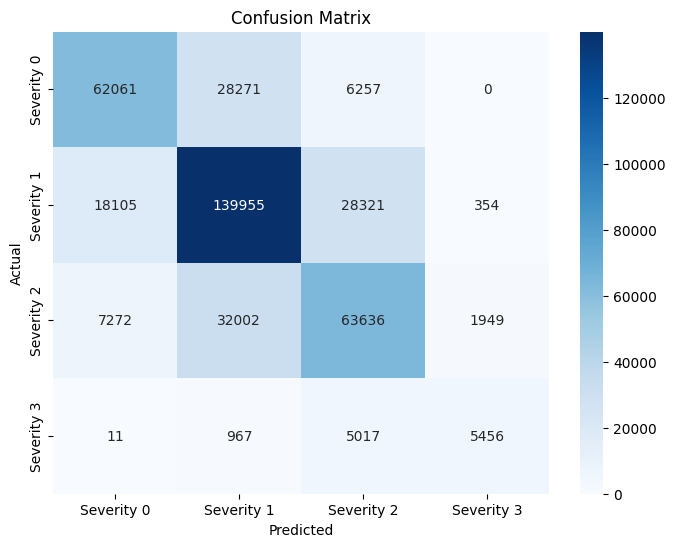

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 100),
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    scoring='accuracy',
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Logistic Regression Test

In [ ]:
# Use feature selected by Random Forest (>=0.0005)
X = df[selected_features]
y = df['Severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Import logisticRegression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on Xtest
y_pred = model.predict(X_test)

KeyboardInterrupt: 

/tmp/ipython-input-18-1923336454.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


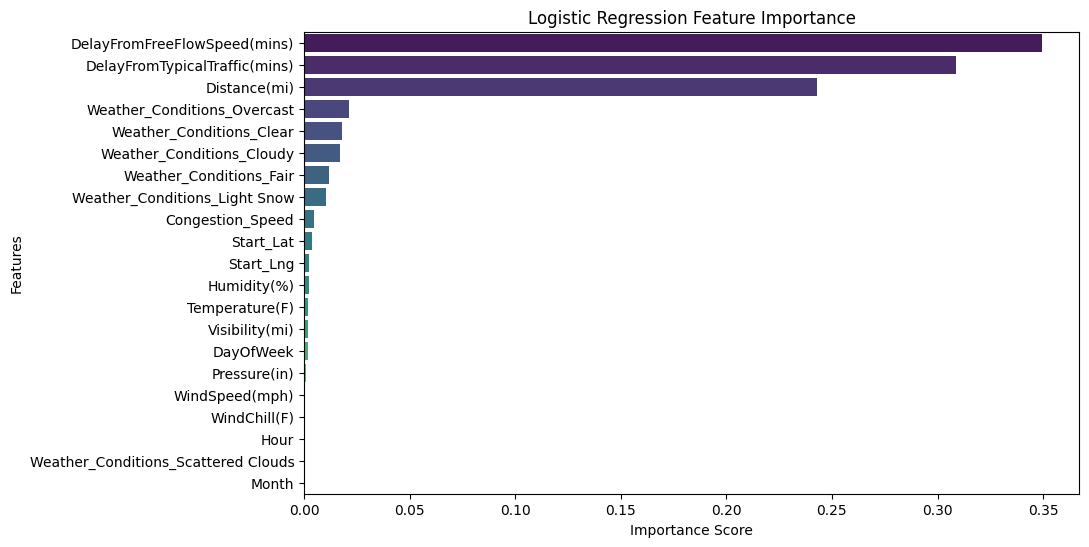


Feature Importance (Logistic Regression):
DelayFromFreeFlowSpeed(mins): 0.349542
DelayFromTypicalTraffic(mins): 0.308780
Congestion_Speed: 0.004672
   Distance(mi): 0.242757
   WindChill(F): 0.000235
      Start_Lng: 0.002284
      Start_Lat: 0.003844
Weather_Conditions_Fair: 0.011825
   Pressure(in): 0.001118
Weather_Conditions_Clear: 0.017850
          Month: 0.000045
 Temperature(F): 0.002112
           Hour: 0.000213
Weather_Conditions_Overcast: 0.021166
Weather_Conditions_Cloudy: 0.016871
 WindSpeed(mph): 0.000658
Weather_Conditions_Scattered Clouds: 0.000056
    Humidity(%): 0.002135
      DayOfWeek: 0.001723
 Visibility(mi): 0.001862
Weather_Conditions_Light Snow: 0.010251


In [ ]:
# Get feature importance
feature_importance = np.abs(model.coef_[0])
feature_importance = feature_importance / feature_importance.sum()

feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Create simple display (higher = more important)
print("\nFeature Importance (Logistic Regression):")
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"{feature:>15}: {importance:.6f}")

Accuracy: 0.52

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.24      0.32     96589
           1       0.52      0.83      0.64    186735
           2       0.55      0.28      0.37    104859
           3       0.08      0.00      0.01     11451

    accuracy                           0.52    399634
   macro avg       0.41      0.34      0.34    399634
weighted avg       0.51      0.52      0.47    399634


Confusion Matrix:
[[ 23327  72396    849     17]
 [ 18391 154293  13879    172]
 [  5780  68889  29881    309]
 [   136   1305   9964     46]]


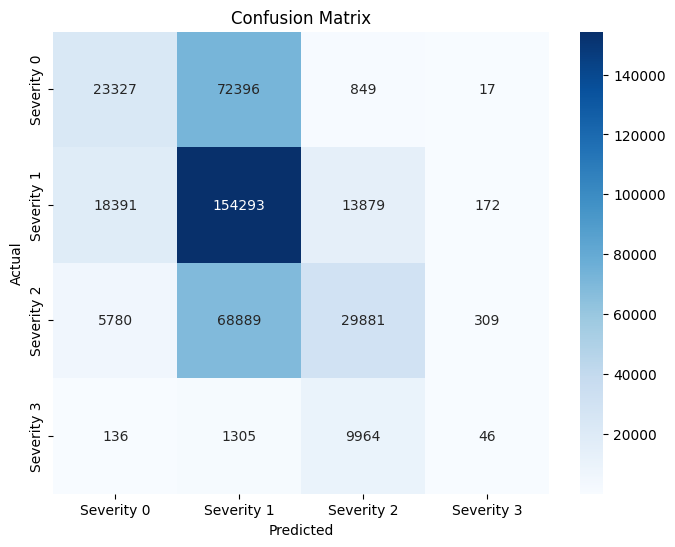

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Hyperparameter

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],  # good for multiclass
    'max_iter': [500, 1000]
}

lr = LogisticRegression(random_state=42)

random_search = RandomizedSearchCV(
    lr,
    param_distributions=param_dist,
    n_iter=4,
    scoring='accuracy',
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Accuracy: 0.52

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.24      0.32     96589
           1       0.52      0.83      0.64    186735
           2       0.55      0.28      0.37    104859
           3       0.08      0.00      0.01     11451

    accuracy                           0.52    399634
   macro avg       0.41      0.34      0.34    399634
weighted avg       0.51      0.52      0.47    399634


Confusion Matrix:
[[ 23327  72396    849     17]
 [ 18391 154293  13879    172]
 [  5780  68889  29881    309]
 [   136   1305   9964     46]]


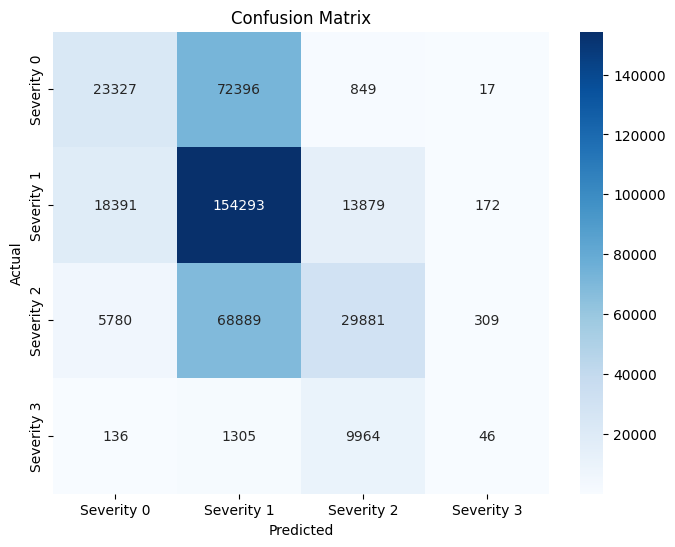

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



XGBoost

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
model = XGBClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-12-2096843571.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


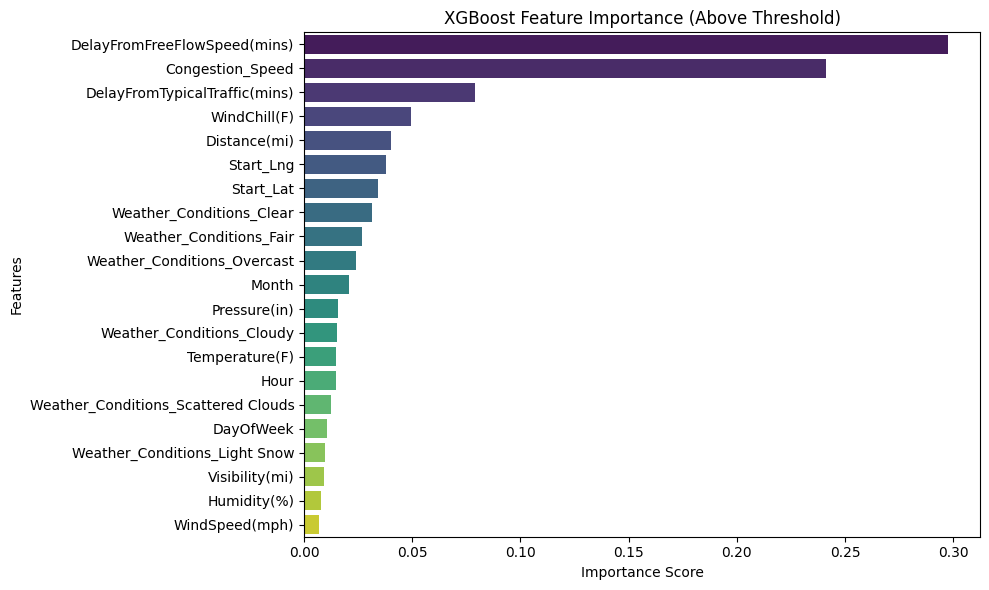


Feature Importance Scores (Above Threshold):
                            Feature  Importance
       DelayFromFreeFlowSpeed(mins)    0.297467
                   Congestion_Speed    0.241407
      DelayFromTypicalTraffic(mins)    0.078933
                       WindChill(F)    0.049321
                       Distance(mi)    0.040395
                          Start_Lng    0.038081
                          Start_Lat    0.034264
           Weather_Conditions_Clear    0.031403
            Weather_Conditions_Fair    0.026964
        Weather_Conditions_Overcast    0.023968
                              Month    0.020720
                       Pressure(in)    0.015791
          Weather_Conditions_Cloudy    0.015339
                     Temperature(F)    0.014881
                               Hour    0.014697
Weather_Conditions_Scattered Clouds    0.012398
                          DayOfWeek    0.010568
      Weather_Conditions_Light Snow    0.009666
                     Visibility(mi)    0.0

In [ ]:
# Get feature importances from the model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance (Above Threshold)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print raw importance values
print("\nFeature Importance Scores (Above Threshold):")
print(importance_df.to_string(index=False))

Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79     96589
           1       0.78      0.82      0.80    186735
           2       0.72      0.72      0.72    104859
           3       0.79      0.66      0.72     11451

    accuracy                           0.78    399634
   macro avg       0.78      0.74      0.76    399634
weighted avg       0.78      0.78      0.78    399634


Confusion Matrix:
[[ 73589  18868   4123      9]
 [ 11501 152970  21884    380]
 [  4108  23308  75831   1612]
 [    15    505   3409   7522]]


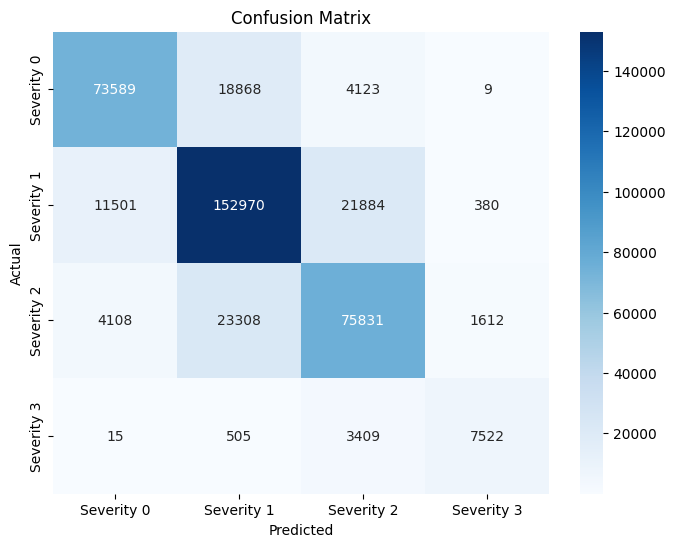

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Hyperparameter

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
}

xgb = XGBClassifier(
    random_state=42,
    n_jobs=1,
    verbosity=0,
    tree_method='hist'  # Faster, lower memory
)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=5,
    scoring='accuracy',
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
Best Accuracy: 0.710394023524054


Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.68      0.71     96589
           1       0.73      0.76      0.75    186735
           2       0.64      0.66      0.65    104859
           3       0.68      0.60      0.64     11451

    accuracy                           0.71    399634
   macro avg       0.70      0.67      0.69    399634
weighted avg       0.71      0.71      0.71    399634


Confusion Matrix:
[[ 65698  24805   6086      0]
 [ 15205 142695  28272    563]
 [  6379  27134  68702   2644]
 [    19    779   3801   6852]]


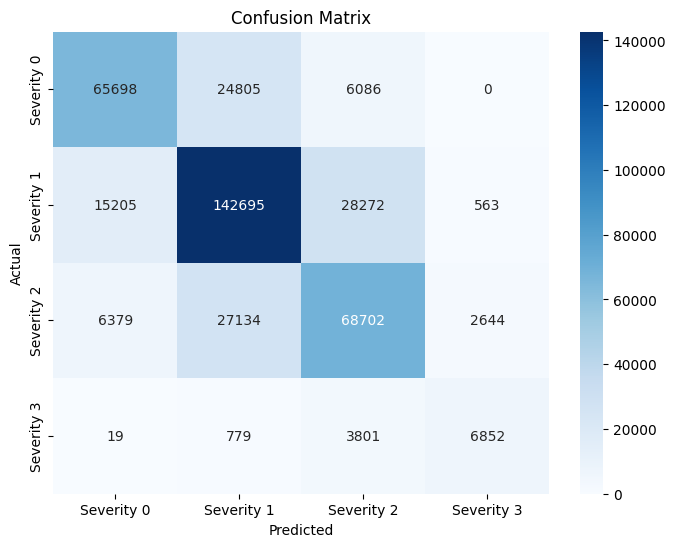

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

/tmp/ipython-input-18-3017039147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


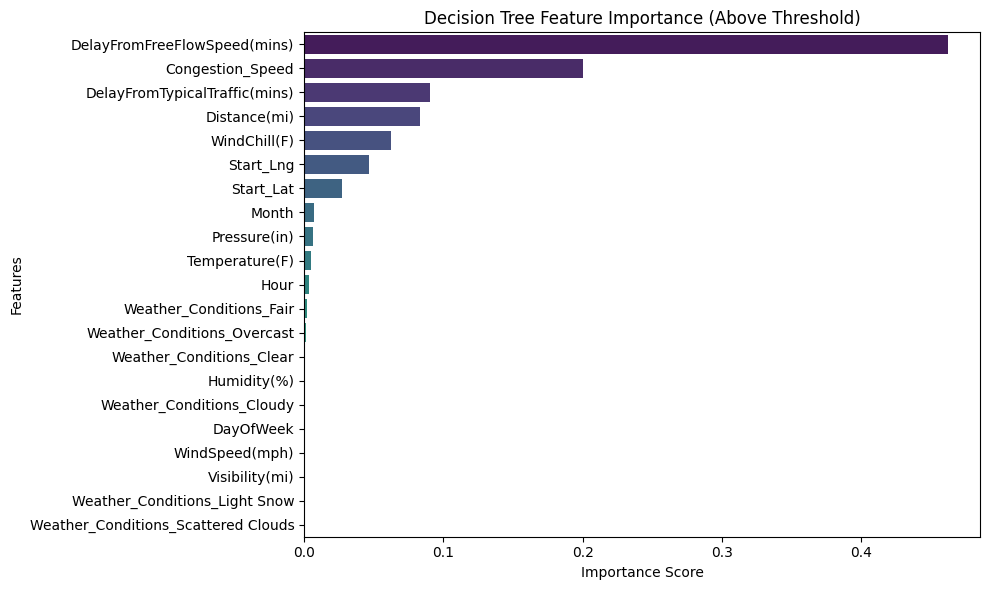


Feature Importance Scores (Above Threshold):
                            Feature  Importance
       DelayFromFreeFlowSpeed(mins)    0.462228
                   Congestion_Speed    0.200486
      DelayFromTypicalTraffic(mins)    0.090357
                       Distance(mi)    0.083316
                       WindChill(F)    0.062532
                          Start_Lng    0.046678
                          Start_Lat    0.026906
                              Month    0.007269
                       Pressure(in)    0.006589
                     Temperature(F)    0.005295
                               Hour    0.003287
            Weather_Conditions_Fair    0.002439
        Weather_Conditions_Overcast    0.001147
           Weather_Conditions_Clear    0.000697
                        Humidity(%)    0.000240
          Weather_Conditions_Cloudy    0.000166
                          DayOfWeek    0.000159
                     WindSpeed(mph)    0.000133
                     Visibility(mi)    0.0

In [ ]:
# Get feature importances from the model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree Feature Importance (Above Threshold)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print raw importance values
print("\nFeature Importance Scores (Above Threshold):")
print(importance_df.to_string(index=False))

Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70     96589
           1       0.70      0.76      0.73    186735
           2       0.63      0.60      0.61    104859
           3       0.67      0.55      0.60     11451

    accuracy                           0.69    399634
   macro avg       0.68      0.64      0.66    399634
weighted avg       0.69      0.69      0.69    399634


Confusion Matrix:
[[ 64737  26148   5704      0]
 [ 17665 142425  26072    573]
 [  7212  32686  62438   2523]
 [    11    903   4294   6243]]


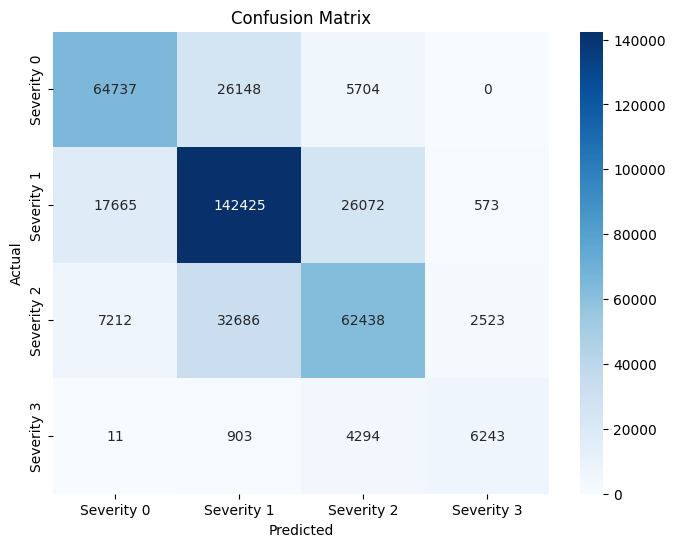

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Hyperparameter

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=5,
    scoring='accuracy',
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'gini'}
Best Accuracy: 0.7087900538868739


Accuracy: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73     96589
           1       0.73      0.78      0.76    186735
           2       0.66      0.64      0.65    104859
           3       0.69      0.59      0.64     11451

    accuracy                           0.72    399634
   macro avg       0.71      0.68      0.69    399634
weighted avg       0.72      0.72      0.72    399634


Confusion Matrix:
[[ 67577  23143   5864      5]
 [ 15414 145478  25284    559]
 [  5880  29096  67476   2407]
 [    29    817   3868   6737]]


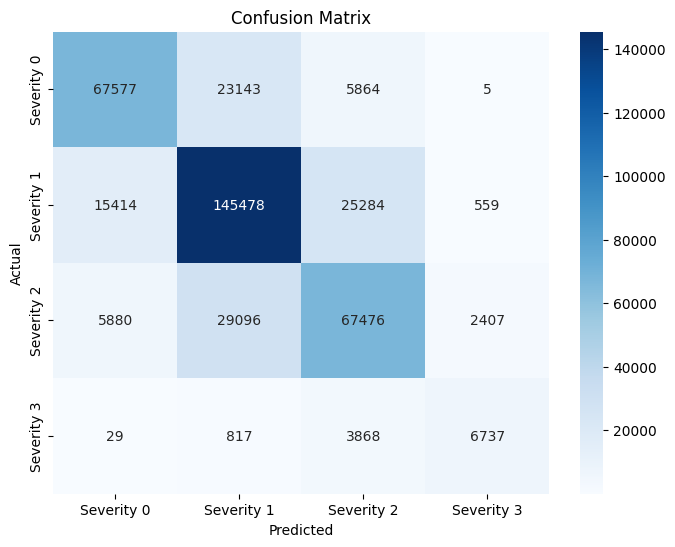

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Support Vector Machine

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-9-2924566797.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


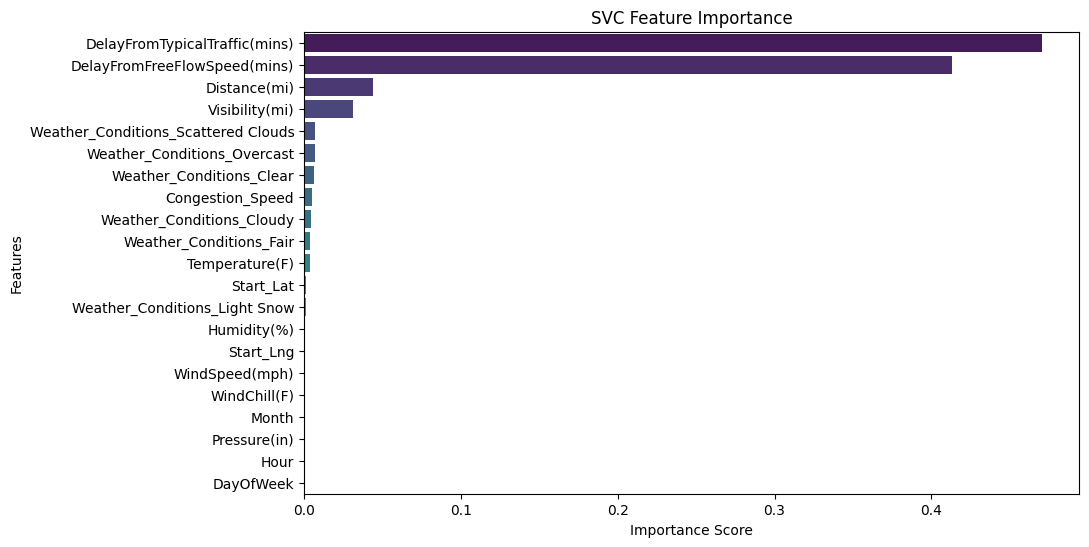


Feature Importance (SVC):
DelayFromFreeFlowSpeed(mins): 0.412960
DelayFromTypicalTraffic(mins): 0.470640
Congestion_Speed: 0.005153
   Distance(mi): 0.044109
   WindChill(F): 0.000094
      Start_Lng: 0.000376
      Start_Lat: 0.001068
Weather_Conditions_Fair: 0.004022
   Pressure(in): 0.000051
Weather_Conditions_Clear: 0.006422
          Month: 0.000089
 Temperature(F): 0.003886
           Hour: 0.000036
Weather_Conditions_Overcast: 0.006826
Weather_Conditions_Cloudy: 0.004144
 WindSpeed(mph): 0.000293
Weather_Conditions_Scattered Clouds: 0.006870
    Humidity(%): 0.000384
      DayOfWeek: 0.000014
 Visibility(mi): 0.031522
Weather_Conditions_Light Snow: 0.001044


In [ ]:
# Get feature importance
feature_importance = np.abs(model.coef_[0])
feature_importance = feature_importance / feature_importance.sum()

feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('SVC Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Create simple display (higher = more important)
print("\nFeature Importance (SVC):")
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"{feature:>15}: {importance:.6f}")

Accuracy: 0.53

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.35      0.43     96589
           1       0.53      0.82      0.64    186735
           2       0.53      0.23      0.32    104859
           3       0.78      0.00      0.01     11451

    accuracy                           0.53    399634
   macro avg       0.60      0.35      0.35    399634
weighted avg       0.54      0.53      0.49    399634


Confusion Matrix:
[[ 33620  62704    265      0]
 [ 21017 153791  11927      0]
 [  6225  74254  24366     14]
 [   155   1417   9828     51]]


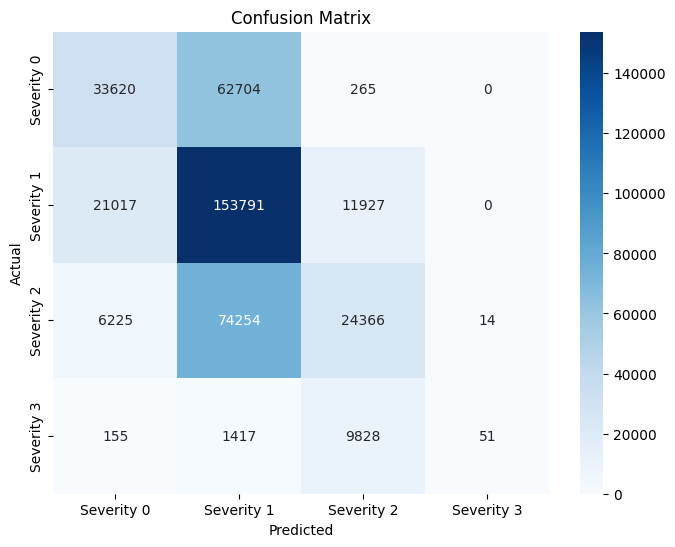

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Hyperparameter
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


param_grid = {
    'linearsvc__C': [0.01, 0.1, 1, 10, 100],
    'linearsvc__loss': ['hinge', 'squared_hinge'],
    'linearsvc__penalty': ['l2'],
    'linearsvc__dual': [False]  # False when n_samples > n_features often helps
}

svc = make_pipeline(StandardScaler(), LinearSVC(max_iter=10000))

search_svc = GridSearchCV(
    svc, param_grid=param_grid,
    scoring='accuracy',
    cv=2, verbose=1, n_jobs=1
)

search_svc.fit(X_train, y_train)

best_model = search_svc.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 2 folds for each of 10 candidates, totalling 20 fits


In [ ]:
print("Best Parameters:", search_svc.best_params_)
print("Best Accuracy:", search_svc.best_score_)

Best Parameters: {'linearsvc__C': 0.1, 'linearsvc__dual': False, 'linearsvc__loss': 'squared_hinge', 'linearsvc__penalty': 'l2'}
Best Accuracy: 0.5313455954017869


Accuracy: 0.53

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.35      0.43     96589
           1       0.53      0.82      0.64    186735
           2       0.53      0.24      0.33    104859
           3       0.51      0.05      0.09     11451

    accuracy                           0.53    399634
   macro avg       0.53      0.36      0.37    399634
weighted avg       0.53      0.53      0.49    399634


Confusion Matrix:
[[ 34068  62174    347      0]
 [ 21232 152583  12769    151]
 [  6273  73154  25049    383]
 [   157   1613   9115    566]]


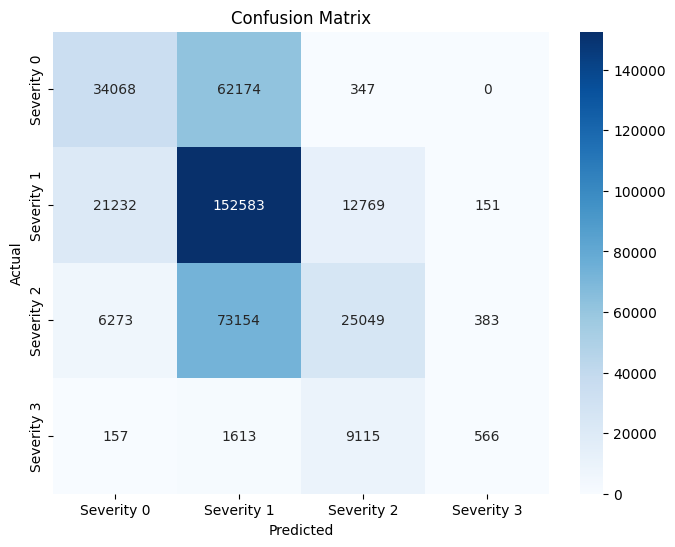

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Define class labels
class_names = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()